In [70]:
import torch
import torchvision
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision import transforms
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms.functional as F
import matplotlib.pyplot as plt
from PIL import Image

In [58]:
import os
os.chdir("C:/Users/gargp/OneDrive/Desktop/DIV2K-SRGAN")

In [59]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.gen = nn.Sequential(
            nn.Conv2d(3,64,3,1,1),
            nn.ReLU(),
            nn.Conv2d(64,64,3,1,1),
            nn.ReLU(),
            nn.ConvTranspose2d(64,64,4,2,1),
            nn.ReLU(),
            nn.Conv2d(64,3,3,1,1),
            nn.Tanh()
        )
    def forward(self,x):
        return self.gen(x)

In [60]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.dis = nn.Sequential(
            nn.Conv2d(3,64,3,2,1),
            nn.LeakyReLU(.2),
            nn.Conv2d(64,128,3,2,1),
            nn.LeakyReLU(.2),
            nn.Conv2d(128,256,3,2,1),
            nn.LeakyReLU(.2),
            nn.Conv2d(256,1,3,1,1),
        )
    def forward(self,x):
        return self.dis(x)

In [80]:
lr = 2e-4
batch_size = 4
loss = nn.BCEWithLogitsLoss()
betas = (.5,.999)
lamb = 0
epochs = 30

In [81]:
disc = Discriminator()
gen = Generator()
disc_optim = optim.Adam(disc.parameters(),betas=betas,lr=lr)
gen_optim = optim.Adam(gen.parameters(),betas=betas,lr=lr)


In [63]:
transform = transforms.Compose([
    transforms.Resize([64,64]),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.5*3],
        std=[0.5]*3
    )
])
dataset = ImageFolder(
    root="Data",
    transform= transform
)
loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

In [89]:
for epoch in range(epochs):
    for real_img, _ in loader:
        real_64 = real_img
        real_32 = F.resize(real_64,[32,32])

        fake = gen(real_32)
        disc_real = disc(real_64).view(-1)
        disc_fake = disc(fake.detach()).view(-1)
        disc_loss_real = loss(disc_real,torch.ones_like(disc_real))
        disc_loss_fake = loss(disc_fake,torch.zeros_like(disc_fake))
        loss_d = disc_loss_real+disc_loss_fake
        disc.zero_grad()
        loss_d.backward()
        disc_optim.step()
        

        output = disc(fake)
        l1_loss = torch.mean(abs(real_64-fake))
        loss_g = l1_loss + lamb*loss(output,torch.ones_like(output))   
        gen.zero_grad()
        loss_g.backward()
        gen_optim.step()

In [69]:
def show_image(tensor):
    img = (tensor+1)/2
    img = img.squeeze(0)
    img = img.permute(1,2,0)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [90]:
image = Image.open("Data/test_images/0801.png").convert("RGB")
image = F.resize(image,[32,32])
image = F.to_tensor(image)
image = F.normalize(image,[0.5]*3,[0.5]*3)

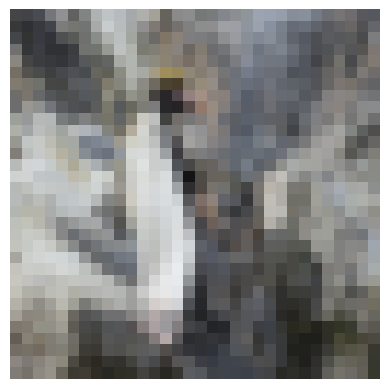

In [91]:
show_image(image)

In [92]:
gen.eval()
with torch.no_grad():
    fake = gen(image)


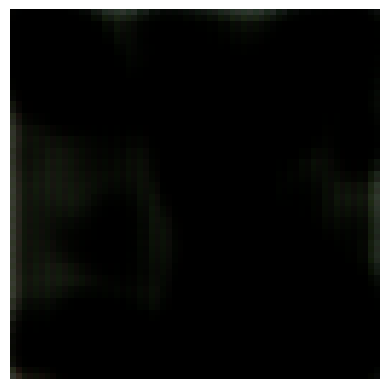

In [97]:
show_image(fake)